# Sparse Identification of Nonlinear Dynamics (SINDy)

Given a time series of measurements from a dynamical system, can we **automatically discover the governing equations** — without knowing the physics in advance?

This is the core question addressed by **SINDy** (Brunton, Proctor & Kutz, 2016). The key insight is that most physical systems have equations of motion that are **sparse** in a library of candidate functions: even though there are infinitely many functions one could write down, nature tends to use only a handful of simple terms (constants, linear terms, low-degree polynomials).

SINDy exploits this sparsity. Given state measurements $\mathbf{X}$ and their time derivatives $\dot{\mathbf{X}}$, it solves:

$$\dot{\mathbf{X}} = \boldsymbol{\Theta}(\mathbf{X})\,\boldsymbol{\Xi}$$

where $\boldsymbol{\Theta}$ is a library of candidate functions and $\boldsymbol{\Xi}$ is the sparse coefficient matrix that we want to identify.

In this notebook we apply SINDy to the **Rössler attractor** — a chaotic 3-D dynamical system whose governing equations we pretend not to know, and then rediscover from data.

## 1. Background: SINDy Algorithm

### Dynamical system

We observe a state $\mathbf{x}(t) \in \mathbb{R}^n$ evolving according to unknown dynamics:

$$\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x})$$

SINDy approximates $\mathbf{f}$ as a sparse linear combination of library functions $\{\theta_j(\mathbf{x})\}$.

### Library construction

Given $N_t$ snapshots, we build the **library matrix** $\boldsymbol{\Theta} \in \mathbb{R}^{N_t \times p}$:

$$\boldsymbol{\Theta}(\mathbf{X}) = \begin{bmatrix} 1 & x & y & z & xy & xz & yz & x^2 & y^2 & z^2 & \cdots \end{bmatrix}$$

Each column is a candidate function evaluated at every time step.

### Sparse regression

We want to solve $\dot{\mathbf{X}} = \boldsymbol{\Theta}\,\boldsymbol{\Xi}$ for the sparse coefficient matrix $\boldsymbol{\Xi} \in \mathbb{R}^{p \times n}$. Standard least squares gives a dense solution; SINDy enforces sparsity through **sequential thresholded least squares (STLS)**:

1. Compute initial estimate: $\boldsymbol{\Xi}^{(0)} = \boldsymbol{\Theta}^\dagger \dot{\mathbf{X}}$
2. For $k = 1, \ldots, K$:
   - Hard-threshold: set $\Xi_{ij}^{(k)} = 0$ whenever $|\Xi_{ij}^{(k-1)}| < \lambda$
   - Re-regress: for each column $j$, refit using only the surviving (non-zero) rows

The threshold $\lambda$ controls the **sparsity level** — too large and real terms are discarded; too small and spurious terms survive.

### The Rössler system

The Rössler attractor is a 3-D chaotic system defined by:

$$\dot{x} = -y - z$$
$$\dot{y} = x + a\,y$$
$$\dot{z} = b + z(x - c)$$

with parameters $a = 0.2$, $b = 0.2$, $c = 5.7$. These equations contain only **linear and bilinear** terms — exactly the kind of sparsity SINDy is designed to exploit.

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

np.random.seed(42)

## 3. Generating the Rössler Attractor

We integrate the Rössler system numerically using `scipy.integrate.odeint` (a wrapper around LSODA) to produce a clean reference trajectory. This trajectory is what we will treat as our "measurements".

The time span $t \in [0, 100]$ with $N_t = 10{,}000$ points gives a time step of $\Delta t = 0.01$ — small enough for accurate finite-difference derivatives later.

In [2]:
def rossler(X, t, a=0.2, b=0.2, c=5.7):
    x, y, z = X
    return [-y - z,
             x + a * y,
             b + z * (x - c)]


t  = np.linspace(0, 100, 10000)
X0 = [0.0, 1.0, 0.0]
X  = odeint(rossler, X0, t)

print(f"Trajectory shape: {X.shape}  (N_t × 3)")
print(f"Time step dt    : {t[1] - t[0]:.4f}")

Trajectory shape: (10000, 3)  (N_t × 3)
Time step dt    : 0.0100


## 4. Visualising the Attractor

Before any analysis we plot the 3-D trajectory. The characteristic folded-band shape of the Rössler attractor is immediately visible — the system spirals outward in the $xy$-plane and then folds back, creating the strange attractor geometry.

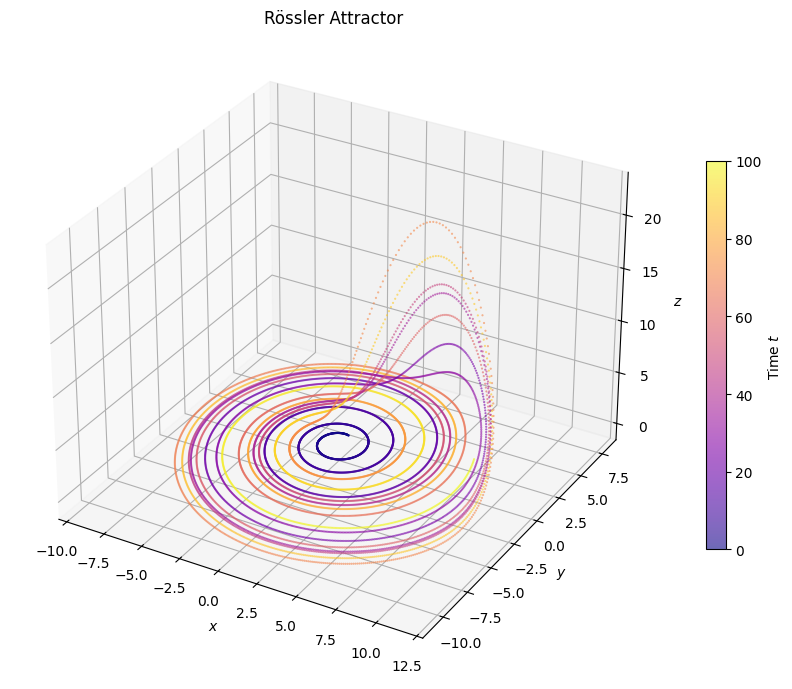

In [3]:
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(X[:, 0], X[:, 1], X[:, 2],
                 c=t, cmap='plasma', s=0.3, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Time $t$', shrink=0.6)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
ax.set_title('Rössler Attractor')
plt.tight_layout()
plt.show()

## 5. Adding Measurement Noise

Real sensor measurements are always corrupted by noise. We add zero-mean Gaussian noise at a controlled signal-to-noise level to test the robustness of SINDy.

The noise amplitude is set relative to the standard deviation of each state variable (5% noise level). This is a realistic scenario — a cleaner trajectory would make SINDy trivially easy, while excessive noise would require more sophisticated derivative estimation.

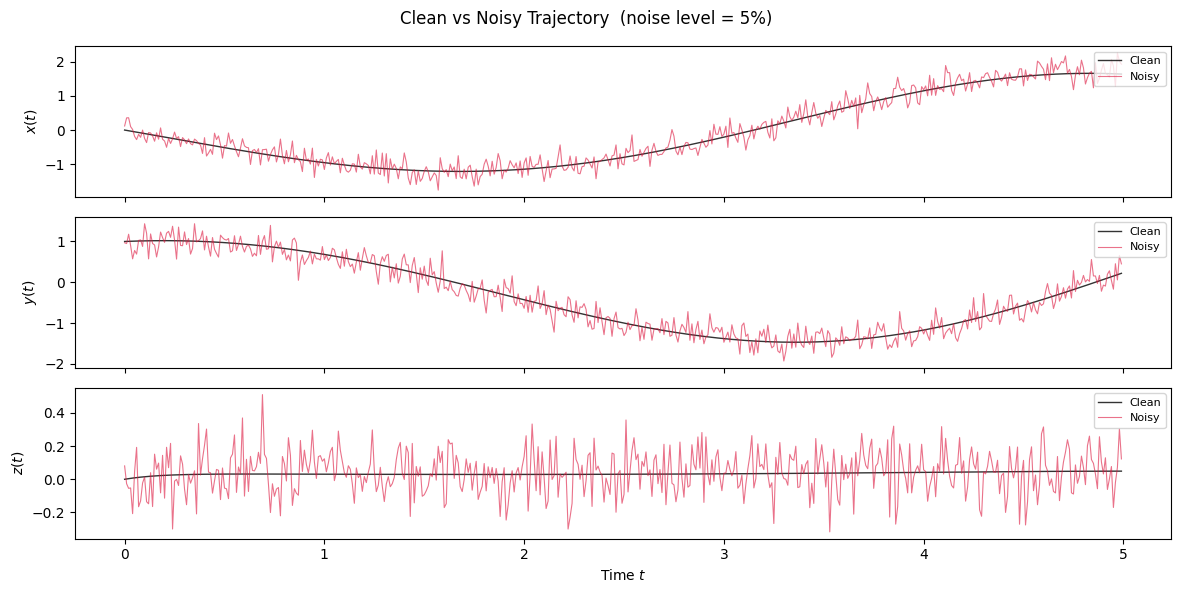

In [4]:
noise_level = 0.05
X_noisy = X + noise_level * np.std(X, axis=0) * np.random.randn(*X.shape)

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
labels = ['$x(t)$', '$y(t)$', '$z(t)$']
for i, (ax, lbl) in enumerate(zip(axes, labels)):
    ax.plot(t[:500], X[:500, i],       color='black',    linewidth=1,   label='Clean',  alpha=0.8)
    ax.plot(t[:500], X_noisy[:500, i], color='crimson',  linewidth=0.8, label='Noisy',  alpha=0.6)
    ax.set_ylabel(lbl)
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time $t$')
plt.suptitle(f'Clean vs Noisy Trajectory  (noise level = {noise_level*100:.0f}%)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Computing Time Derivatives

SINDy requires the time derivatives $\dot{\mathbf{X}}$. We estimate them using a **second-order central finite difference**:

$$\dot{x}_i \approx \frac{x_{i+1} - x_{i-1}}{2\Delta t}$$

Central differences are more accurate than forward differences (error $\mathcal{O}(\Delta t^2)$ vs $\mathcal{O}(\Delta t)$) and are symmetric around the evaluation point. We lose the first and last point, so both $\mathbf{X}$ and $\dot{\mathbf{X}}$ are trimmed to the interior points.

In [5]:
dt = t[1] - t[0]
dX = (X_noisy[2:] - X_noisy[:-2]) / (2 * dt)   # central differences
X_trim = X_noisy[1:-1]                           # trim to match dX length

print(f"Trimmed trajectory shape : {X_trim.shape}")
print(f"Derivative matrix shape  : {dX.shape}")

Trimmed trajectory shape : (9998, 3)
Derivative matrix shape  : (9998, 3)


## 7. Building the Function Library

We construct $\boldsymbol{\Theta}$ using all polynomial terms up to degree 2:

$$\boldsymbol{\Theta} = \begin{bmatrix} 1 & x & y & z & xy & xz & yz & x^2 & y^2 & z^2 \end{bmatrix}$$

This gives $p = 10$ candidate functions. For the Rössler system all governing terms are within this library (the nonlinear terms are $xz$ in the $\dot{z}$ equation).

Choosing the right library is a modelling decision — a library that is too small will miss real dynamics; one that is too large adds unnecessary candidates that increase the risk of spurious identifications.

In [6]:
x, y, z = X_trim[:, 0], X_trim[:, 1], X_trim[:, 2]

Theta = np.column_stack([
    np.ones_like(x),   # 1
    x, y, z,           # linear
    x*y, x*z, y*z,     # bilinear
    x**2, y**2, z**2,  # quadratic
])

lib_names = ['1', 'x', 'y', 'z', 'xy', 'xz', 'yz', 'x²', 'y²', 'z²']

print(f"Library matrix shape: {Theta.shape}  (N_t × p)")
print(f"Library terms       : {lib_names}")

Library matrix shape: (9998, 10)  (N_t × p)
Library terms       : ['1', 'x', 'y', 'z', 'xy', 'xz', 'yz', 'x²', 'y²', 'z²']


## 8. The SINDy Algorithm

The core of SINDy is **sequential thresholded least squares (STLS)**. The algorithm alternates between:

- **Thresholding**: zeroing out coefficients whose magnitude falls below $\lambda$ (enforcing sparsity).
- **Regression**: refitting the remaining non-zero coefficients via least squares on the reduced library.

This is analogous to hard-thresholding in compressed sensing, but adapted to the regression setting where the library columns may be correlated.

In [7]:
def sindy(Theta, dXdt, lambd, n_iter=10):
    """
    Sequential Thresholded Least Squares.

    Parameters
    ----------
    Theta  : (N, p) library matrix
    dXdt   : (N, n) derivative matrix
    lambd  : sparsification threshold
    n_iter : number of thresholding iterations

    Returns
    -------
    Xi : (p, n) sparse coefficient matrix
    """
    Xi = np.linalg.lstsq(Theta, dXdt, rcond=None)[0]  # initial dense estimate

    for _ in range(n_iter):
        small = np.abs(Xi) < lambd
        Xi[small] = 0.0

        for j in range(dXdt.shape[1]):
            active = ~small[:, j]
            if active.any():
                Xi[active, j] = np.linalg.lstsq(
                    Theta[:, active], dXdt[:, j], rcond=None
                )[0]
    return Xi


lambd = 0.1
Xi    = sindy(Theta, dX, lambd)

print(f"Coefficient matrix shape: {Xi.shape}  (p × n)")

Coefficient matrix shape: (10, 3)  (p × n)


## 9. Identified Equations

Each column of $\boldsymbol{\Xi}$ gives the coefficients for one state equation. Non-zero entries correspond to the **active terms** in the discovered governing equations.

We print the identified equations in human-readable form and compare them to the known Rössler dynamics:

$$\dot{x} = -y - z \qquad \dot{y} = x + 0.2\,y \qquad \dot{z} = 0.2 + xz - 5.7\,z$$

In [8]:
state_names = ['ẋ', 'ẏ', 'ż']

print("Identified governing equations\n" + "=" * 40)
for j, name in enumerate(state_names):
    terms = []
    for i, (coef, lib) in enumerate(zip(Xi[:, j], lib_names)):
        if abs(coef) > 1e-6:
            terms.append(f"({coef:+.4f}) {lib}")
    eq = "  +  ".join(terms) if terms else "0"
    print(f"  {name} = {eq}")

print()
print("True Rössler equations")
print("=" * 40)
print("  ẋ = -y - z")
print("  ẏ = x + 0.2 y")
print("  ż = 0.2 + xz - 5.7 z")

Identified governing equations
  ẋ = (-1.0001) y  +  (-0.9997) z
  ẏ = (+0.9962) x  +  (+0.1997) y
  ż = (+0.1936) 1  +  (-5.5858) z  +  (+0.9786) xz

True Rössler equations
  ẋ = -y - z
  ẏ = x + 0.2 y
  ż = 0.2 + xz - 5.7 z


## 10. Coefficient Matrix Visualisation

A heatmap of $\boldsymbol{\Xi}$ gives an immediate visual check of sparsity: most entries should be white (zero), with a handful of coloured cells corresponding to the identified active terms.

This is a useful diagnostic — a dense $\boldsymbol{\Xi}$ suggests the threshold $\lambda$ is too small or the library is under-complete.

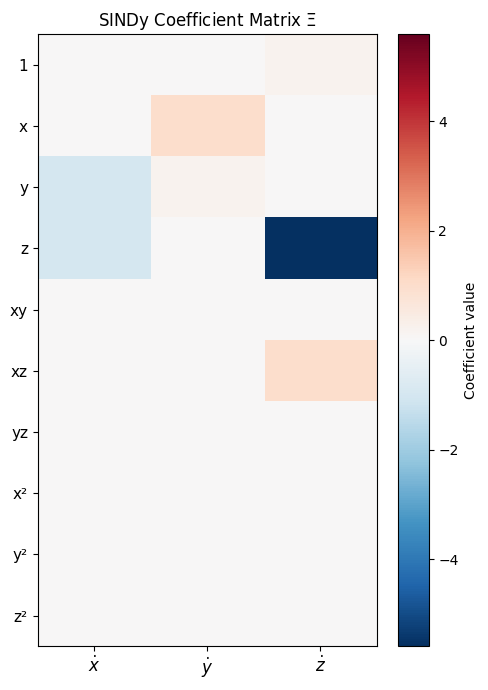

In [9]:
fig, ax = plt.subplots(figsize=(5, 7))
im = ax.imshow(Xi, cmap='RdBu_r', aspect='auto',
               vmin=-np.abs(Xi).max(), vmax=np.abs(Xi).max())
plt.colorbar(im, ax=ax, label='Coefficient value')
ax.set_xticks(range(3))
ax.set_xticklabels(['$\\dot{x}$', '$\\dot{y}$', '$\\dot{z}$'], fontsize=12)
ax.set_yticks(range(len(lib_names)))
ax.set_yticklabels(lib_names, fontsize=11)
ax.set_title('SINDy Coefficient Matrix $\\Xi$', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Effect of the Sparsification Threshold $\lambda$

The threshold $\lambda$ is the key hyperparameter of SINDy. We sweep it over two orders of magnitude and track:
- The **number of active terms** (non-zero entries in $\boldsymbol{\Xi}$).
- The **mean squared reconstruction error** $\|\boldsymbol{\Theta}\boldsymbol{\Xi} - \dot{\mathbf{X}}\|_F^2 / N$.

The optimal $\lambda$ sits in the region where the error is low but the model is still sparse — the classic **bias-variance trade-off** in model selection.

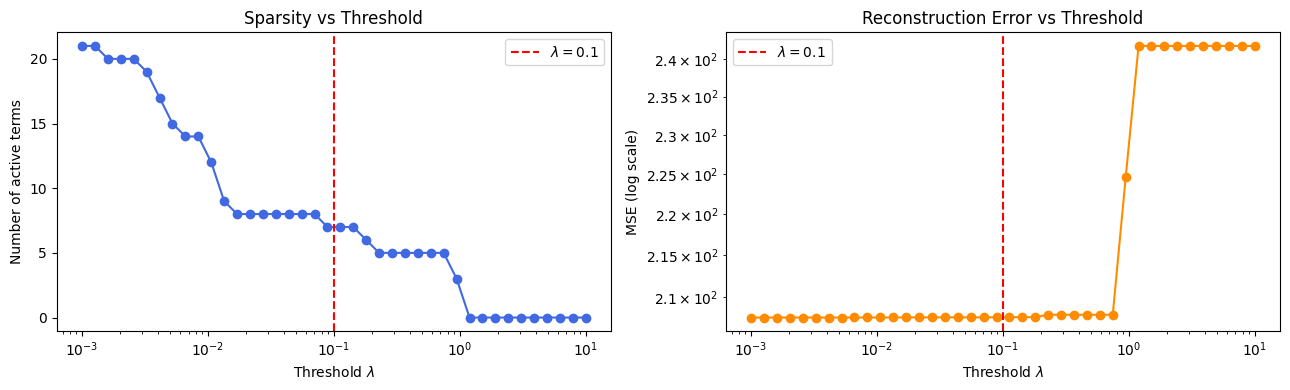

In [10]:
lambdas    = np.logspace(-3, 1, 40)
n_terms    = []
mse_vals   = []

for lam in lambdas:
    Xi_lam = sindy(Theta, dX, lam)
    n_terms.append(np.sum(np.abs(Xi_lam) > 1e-8))
    residual = Theta @ Xi_lam - dX
    mse_vals.append(np.mean(residual ** 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(lambdas, n_terms, 'o-', color='royalblue')
axes[0].axvline(0.1, color='red', linestyle='--', label='$\\lambda = 0.1$')
axes[0].set_xlabel('Threshold $\\lambda$')
axes[0].set_ylabel('Number of active terms')
axes[0].set_title('Sparsity vs Threshold')
axes[0].legend()

axes[1].loglog(lambdas, mse_vals, 'o-', color='darkorange')
axes[1].axvline(0.1, color='red', linestyle='--', label='$\\lambda = 0.1$')
axes[1].set_xlabel('Threshold $\\lambda$')
axes[1].set_ylabel('MSE (log scale)')
axes[1].set_title('Reconstruction Error vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Validating the Discovered Model

The ultimate test: integrate the *discovered* equations forward in time and compare the trajectory to the ground truth. If SINDy found the right equations, the two trajectories should match — at least over short to medium time horizons.

Chaotic systems like the Rössler attractor have sensitive dependence on initial conditions, so even a perfect model will diverge from the true trajectory eventually due to floating-point differences. What we check is that the **attractor geometry** is correctly reproduced.

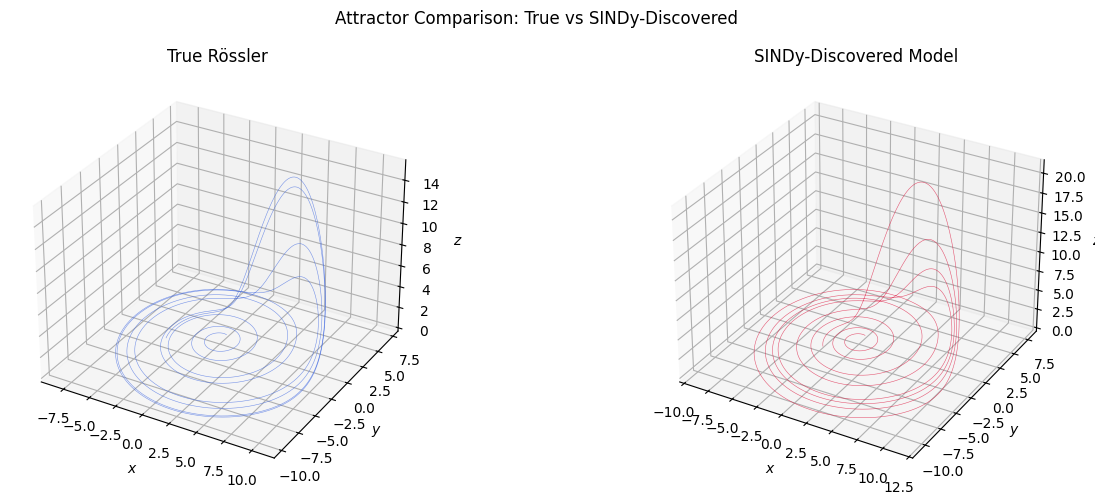

In [11]:
def discovered_model(X_state, t_val, Xi, Theta_fn):
    """RHS evaluated using the SINDy-identified coefficients."""
    theta_row = Theta_fn(X_state)
    return theta_row @ Xi


def build_theta_row(X_state):
    """Evaluate the library at a single state vector."""
    xv, yv, zv = X_state
    return np.array([1, xv, yv, zv, xv*yv, xv*zv, yv*zv, xv**2, yv**2, zv**2])


t_val   = np.linspace(0, 50, 5000)
X_disc  = odeint(discovered_model, X0, t_val, args=(Xi, build_theta_row))
X_true  = odeint(rossler, X0, t_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_plot, title, col in zip(
    axes,
    [X_true, X_disc],
    ['True Rössler', 'SINDy-Discovered Model'],
    ['royalblue', 'crimson']
):
    ax3d = fig.add_subplot(1, 2, axes.tolist().index(ax) + 1, projection='3d')
    ax3d.plot(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2], lw=0.4, color=col, alpha=0.7)
    ax3d.set_xlabel('$x$'); ax3d.set_ylabel('$y$'); ax3d.set_zlabel('$z$')
    ax3d.set_title(title)

for ax in axes:
    ax.remove()

plt.suptitle('Attractor Comparison: True vs SINDy-Discovered', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Summary and Key Takeaways

| | |
|---|---|
| **System** | Rössler attractor ($a=0.2$, $b=0.2$, $c=5.7$) |
| **Data** | $N_t = 10{,}000$ snapshots, noise level 5% |
| **Library** | Polynomial terms up to degree 2 ($p = 10$ functions) |
| **Algorithm** | Sequential thresholded least squares (STLS) |
| **Threshold** | $\lambda = 0.1$ |
| **Derivatives** | Central finite differences, $\mathcal{O}(\Delta t^2)$ |

### Key takeaways

- **Sparsity is the key prior**: physical systems tend to have few active terms. SINDy leverages this to produce interpretable, parsimonious models.
- **Threshold $\lambda$ is critical**: too small → dense, over-fit model; too large → under-fit model that discards real dynamics. The sparsity–error trade-off plot (Section 11) guides selection.
- **Derivative estimation matters**: for noisy data, central differences are more accurate than forward differences. More advanced approaches (total variation regularisation, polynomial fitting) can handle higher noise levels.
- **Library design is a modelling choice**: SINDy can only identify terms that are in the library. Domain knowledge about the expected physics helps restrict the search space and improve identifiability.
- **Chaotic systems are still identifiable**: even though two trajectories with slightly different initial conditions diverge exponentially, SINDy correctly recovers the attractor geometry and governing equations from a single trajectory.